In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/anubhavgoyal10/laptop-prices-dataset/laptopPrice.csv")

In [3]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [4]:
df.shape

(823, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              823 non-null    object
 1   processor_brand    823 non-null    object
 2   processor_name     823 non-null    object
 3   processor_gnrtn    823 non-null    object
 4   ram_gb             823 non-null    object
 5   ram_type           823 non-null    object
 6   ssd                823 non-null    object
 7   hdd                823 non-null    object
 8   os                 823 non-null    object
 9   os_bit             823 non-null    object
 10  graphic_card_gb    823 non-null    object
 11  weight             823 non-null    object
 12  warranty           823 non-null    object
 13  Touchscreen        823 non-null    object
 14  msoffice           823 non-null    object
 15  Price              823 non-null    int64 
 16  rating             823 non-null    object
 1

In [7]:
df.isnull().sum()

brand                0
processor_brand      0
processor_name       0
processor_gnrtn      0
ram_gb               0
ram_type             0
ssd                  0
hdd                  0
os                   0
os_bit               0
graphic_card_gb      0
weight               0
warranty             0
Touchscreen          0
msoffice             0
Price                0
rating               0
Number of Ratings    0
Number of Reviews    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(21)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Price,Number of Ratings,Number of Reviews
count,802.000000,802.00000,802.000000
mean,76625.543641,299.84414,36.089776
std,45232.984422,1001.78442,118.313553
min,16990.000000,0.00000,0.000000
25%,45990.000000,0.00000,0.000000
50%,63990.000000,17.00000,2.000000
75%,89525.000000,140.25000,18.000000
max,441990.000000,15279.00000,1947.000000


In [13]:
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique()[:10])

brand
['ASUS' 'Lenovo' 'acer' 'Avita' 'HP' 'DELL' 'MSI' 'APPLE']
processor_brand
['Intel' 'AMD' 'M1']
processor_name
['Core i3' 'Core i5' 'Celeron Dual' 'Ryzen 5' 'Core i7' 'Core i9' 'M1'
 'Pentium Quad' 'Ryzen 3' 'Ryzen 7']
processor_gnrtn
['10th' 'Not Available' '11th' '7th' '8th' '9th' '4th' '12th']
ram_gb
['4 GB' '8 GB' '16 GB' '32 GB']
ram_type
['DDR4' 'LPDDR4' 'LPDDR4X' 'DDR5' 'DDR3' 'LPDDR3']
ssd
['0 GB' '512 GB' '256 GB' '128 GB' '1024 GB' '2048 GB' '3072 GB']
hdd
['1024 GB' '0 GB' '512 GB' '2048 GB']
os
['Windows' 'DOS' 'Mac']
os_bit
['64-bit' '32-bit']
graphic_card_gb
['0 GB' '2 GB' '4 GB' '6 GB' '8 GB']
weight
['Casual' 'ThinNlight' 'Gaming']
warranty
['No warranty' '1 year' '2 years' '3 years']
Touchscreen
['No' 'Yes']
msoffice
['No' 'Yes']
Price
[34649 38999 39999 69990 26990 22990 21990 58799 49999 59990]
rating
['2 stars' '3 stars' '4 stars' '5 stars' '1 star']
Number of Ratings
[   3   65    8    0   31 1946  259  425 1120  286]
Number of Reviews
[  0   5   1   3 240  4

In [16]:
df['brand'].unique()

array(['ASUS', 'Lenovo', 'acer', 'Avita', 'HP', 'DELL', 'MSI', 'APPLE'],
      dtype=object)

In [17]:
df['brand'].value_counts()

brand
ASUS      243
DELL      149
Lenovo    144
HP        136
acer       51
MSI        50
APPLE      23
Avita       6
Name: count, dtype: int64

In [19]:
df['processor_brand'].unique()

array(['Intel', 'AMD', 'M1'], dtype=object)

In [20]:
df['processor_brand'].value_counts()

processor_brand
Intel    594
AMD      189
M1        19
Name: count, dtype: int64

In [21]:
df['processor_name'].value_counts()

processor_name
Core i5         284
Core i3         161
Core i7         104
Ryzen 5          82
Ryzen 7          56
Ryzen 9          26
Ryzen 3          26
Celeron Dual     23
M1               19
Pentium Quad     13
Core i9           8
Name: count, dtype: int64

In [22]:
df['processor_gnrtn'].value_counts()

processor_gnrtn
11th             328
Not Available    224
10th             198
8th               35
7th                7
9th                6
12th               3
4th                1
Name: count, dtype: int64

In [23]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [24]:
df['ram_gb'].value_counts()

ram_gb
8 GB     404
4 GB     223
16 GB    173
32 GB      2
Name: count, dtype: int64

In [25]:
df['ram_type'].value_counts()

ram_type
DDR4       690
LPDDR4X     56
LPDDR4      27
LPDDR3      14
DDR5         8
DDR3         7
Name: count, dtype: int64

In [26]:
df['ssd'].value_counts()

ssd
512 GB     389
256 GB     174
0 GB       123
1024 GB    110
128 GB       3
2048 GB      2
3072 GB      1
Name: count, dtype: int64

In [27]:
df['hdd'].value_counts()

hdd
0 GB       602
1024 GB    159
512 GB      40
2048 GB      1
Name: count, dtype: int64

In [28]:
df['os'].value_counts()

os
Windows    763
Mac         23
DOS         16
Name: count, dtype: int64

In [29]:
df['os'].value_counts()

os
Windows    763
Mac         23
DOS         16
Name: count, dtype: int64

In [30]:
df['os_bit'].value_counts()

os_bit
64-bit    693
32-bit    109
Name: count, dtype: int64

In [31]:
df['graphic_card_gb'].value_counts()

graphic_card_gb
0 GB    557
4 GB    127
2 GB     67
6 GB     37
8 GB     14
Name: count, dtype: int64

In [32]:
df['weight'].value_counts()

weight
Casual        509
ThinNlight    254
Gaming         39
Name: count, dtype: int64

In [33]:
df['warranty'].value_counts()

warranty
1 year         498
No warranty    268
2 years         23
3 years         13
Name: count, dtype: int64

In [34]:
df['Touchscreen'].value_counts()

Touchscreen
No     706
Yes     96
Name: count, dtype: int64

In [35]:
df['msoffice'].value_counts()

msoffice
No     522
Yes    280
Name: count, dtype: int64

In [36]:
df['rating'].value_counts()

rating
4 stars    437
3 stars    338
5 stars     16
2 stars      9
1 star       2
Name: count, dtype: int64

In [40]:
df["brand"] = df["brand"].str.title()

In [41]:
df['ram_gb'] = df['ram_gb'].str.replace(" GB", "", regex=False).astype(int)

In [42]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [44]:
df['os_bit'] = df['os_bit'].str.replace("-bit", "", regex=False).astype(int)

In [45]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0 GB,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512 GB,0 GB,Windows,32,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0 GB,512 GB,Windows,64,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [46]:
df['ssd'] = df['ssd'].str.replace("GB", "", regex=False).astype(int)

In [47]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024 GB,Windows,64,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0 GB,Windows,32,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512 GB,Windows,64,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [48]:
df['hdd'] = df['hdd'].str.replace("GB", "", regex=False).astype(int)

In [49]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [50]:
df['graphic_card_gb'] = df['graphic_card_gb'].str.replace(" GB", "", regex=False).astype(int)

In [51]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,39999,3 stars,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,No warranty,No,No,69990,3 stars,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,No warranty,No,No,26990,3 stars,0,0


In [53]:
df['rating'] = df['rating'].str.replace("stars", "", regex=False)

In [56]:
df['rating'] = df['rating'].str.replace(" star", "", regex=False).astype(int)

In [57]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,No warranty,No,No,39999,3,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,No warranty,No,No,69990,3,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,No warranty,No,No,26990,3,0,0


In [59]:
df['warranty'].value_counts()

warranty
1 year         498
No warranty    268
2 years         23
3 years         13
Name: count, dtype: int64

In [63]:
df['warranty'] = df['warranty'].replace({"No warranty": 0 , "1 year": 1,"2 years" : 2,"3 years" : 3}, regex=False).astype(int)

In [64]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,No,No,39999,3,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,0,No,No,69990,3,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,0,No,No,26990,3,0,0


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              802 non-null    object
 1   processor_brand    802 non-null    object
 2   processor_name     802 non-null    object
 3   processor_gnrtn    802 non-null    object
 4   ram_gb             802 non-null    int64 
 5   ram_type           802 non-null    object
 6   ssd                802 non-null    int64 
 7   hdd                802 non-null    int64 
 8   os                 802 non-null    object
 9   os_bit             802 non-null    int64 
 10  graphic_card_gb    802 non-null    int64 
 11  weight             802 non-null    object
 12  warranty           802 non-null    int64 
 13  Touchscreen        802 non-null    object
 14  msoffice           802 non-null    object
 15  Price              802 non-null    int64 
 16  rating             802 non-null    int64 
 17  Nu

In [67]:
df['Touchscreen'].value_counts()

Touchscreen
No     706
Yes     96
Name: count, dtype: int64

In [69]:
df['Touchscreen'] = df['Touchscreen'].replace({"Yes": 1 , "No": 0,}, regex=False).astype(int)

In [70]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,No,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,No,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,No,39999,3,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,0,0,No,69990,3,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,0,0,No,26990,3,0,0


In [72]:
df['msoffice'] = df['msoffice'].replace({"Yes": 1 , "No": 0,}, regex=False).astype(int)

In [73]:
df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,Asus,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,0,34649,2,3,0
1,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,0,38999,3,65,5
2,Lenovo,Intel,Core i3,10th,4,DDR4,0,1024,Windows,64,0,Casual,0,0,0,39999,3,8,1
3,Asus,Intel,Core i5,10th,8,DDR4,512,0,Windows,32,2,Casual,0,0,0,69990,3,0,0
4,Asus,Intel,Celeron Dual,Not Available,4,DDR4,0,512,Windows,64,0,Casual,0,0,0,26990,3,0,0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   brand              802 non-null    object
 1   processor_brand    802 non-null    object
 2   processor_name     802 non-null    object
 3   processor_gnrtn    802 non-null    object
 4   ram_gb             802 non-null    int64 
 5   ram_type           802 non-null    object
 6   ssd                802 non-null    int64 
 7   hdd                802 non-null    int64 
 8   os                 802 non-null    object
 9   os_bit             802 non-null    int64 
 10  graphic_card_gb    802 non-null    int64 
 11  weight             802 non-null    object
 12  warranty           802 non-null    int64 
 13  Touchscreen        802 non-null    int64 
 14  msoffice           802 non-null    int64 
 15  Price              802 non-null    int64 
 16  rating             802 non-null    int64 
 17  Nu

In [76]:
categorical_columns = [
    "brand",
    "processor_brand",
    "processor_name",
    "processor_gnrtn",
    "ram_type",
    "os",
    "os_bit",
    "weight"
]

In [77]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)

In [78]:
df.head()

,ram_gb,ssd,hdd,graphic_card_gb,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,...,ram_type_DDR4,ram_type_DDR5,ram_type_LPDDR3,ram_type_LPDDR4,ram_type_LPDDR4X,os_Mac,os_Windows,os_bit_64,weight_Gaming,weight_ThinNlight
0,4,0,1024,0,0,0,0,34649,2,3,...,1,0,0,0,0,0,1,1,0,0
1,4,0,1024,0,0,0,0,38999,3,65,...,1,0,0,0,0,0,1,1,0,0
2,4,0,1024,0,0,0,0,39999,3,8,...,1,0,0,0,0,0,1,1,0,0
3,8,512,0,2,0,0,0,69990,3,0,...,1,0,0,0,0,0,1,0,0,0
4,4,0,512,0,0,0,0,26990,3,0,...,1,0,0,0,0,0,1,1,0,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 802 entries, 0 to 822
Data columns (total 47 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ram_gb                         802 non-null    int64
 1   ssd                            802 non-null    int64
 2   hdd                            802 non-null    int64
 3   graphic_card_gb                802 non-null    int64
 4   warranty                       802 non-null    int64
 5   Touchscreen                    802 non-null    int64
 6   msoffice                       802 non-null    int64
 7   Price                          802 non-null    int64
 8   rating                         802 non-null    int64
 9   Number of Ratings              802 non-null    int64
 10  Number of Reviews              802 non-null    int64
 11  brand_Apple                    802 non-null    int64
 12  brand_Asus                     802 non-null    int64
 13  brand_Avita              

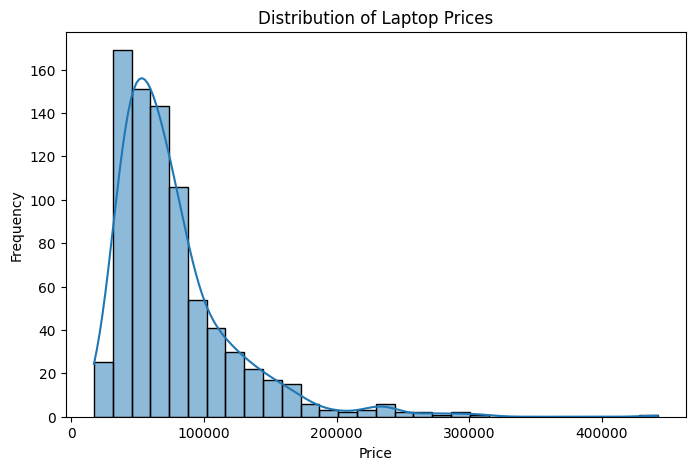

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

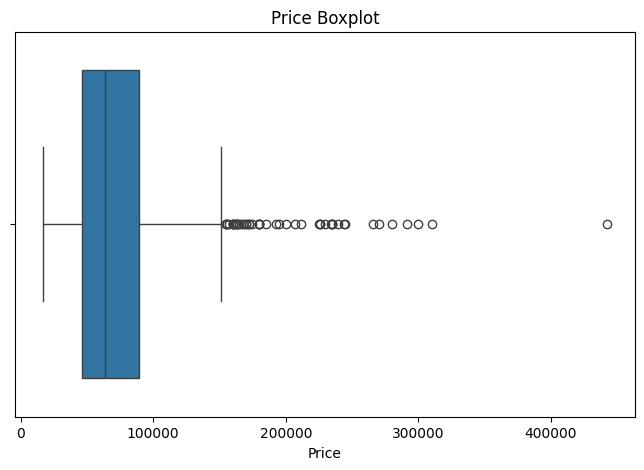

In [81]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Price Boxplot")

plt.show()

In [82]:
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)

corr

Price                            1.000000
ssd                              0.628734
ram_gb                           0.516454
graphic_card_gb                  0.467499
processor_name_Core i7           0.391785
processor_name_Core i9           0.363030
brand_Apple                      0.305822
os_Mac                           0.305822
processor_name_M1                0.265689
processor_brand_M1               0.265689
processor_name_Ryzen 9           0.256656
processor_gnrtn_12th             0.221442
Touchscreen                      0.191227
ram_type_LPDDR3                  0.183537
ram_type_LPDDR4X                 0.175924
ram_type_DDR5                    0.170677
brand_Msi                        0.125991
processor_name_Ryzen 7           0.063281
warranty                         0.057953
processor_gnrtn_8th              0.046828
brand_Asus                       0.040846
ram_type_LPDDR4                  0.028823
processor_gnrtn_9th              0.021638
weight_Gaming                   -0

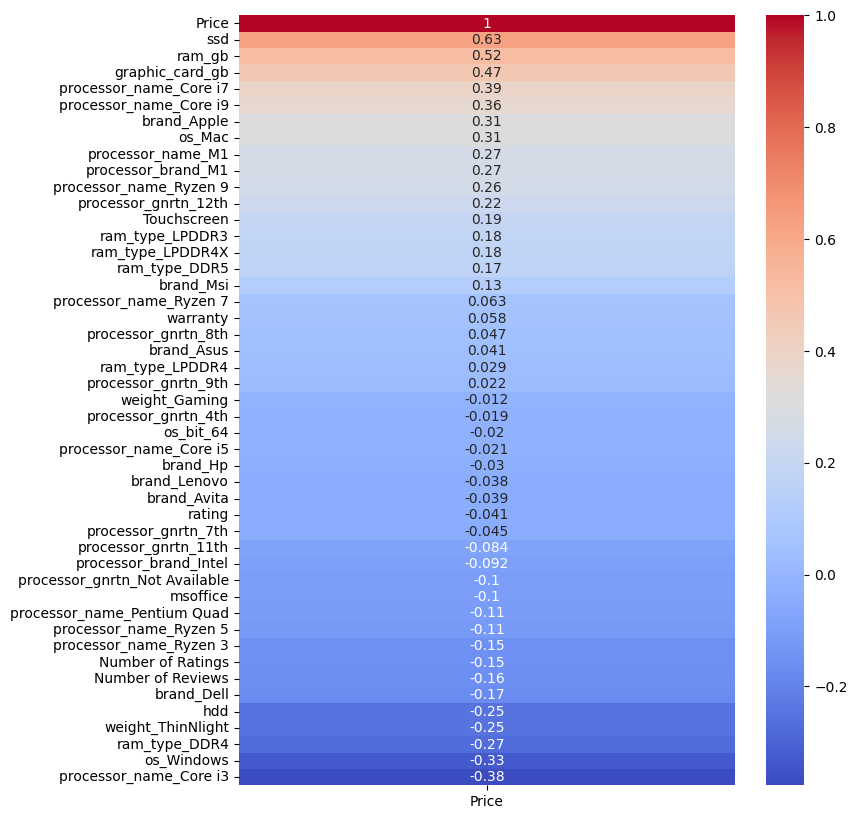

In [89]:
corr = (
    df.corr(numeric_only=True)["Price"]
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

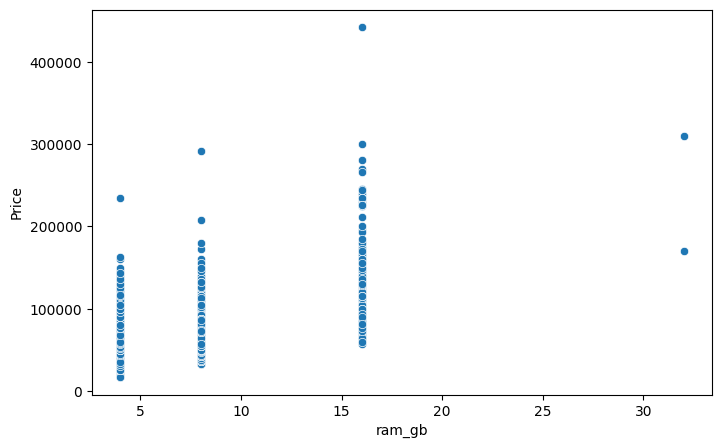

In [85]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ram_gb",
    y="Price"
)

plt.show()

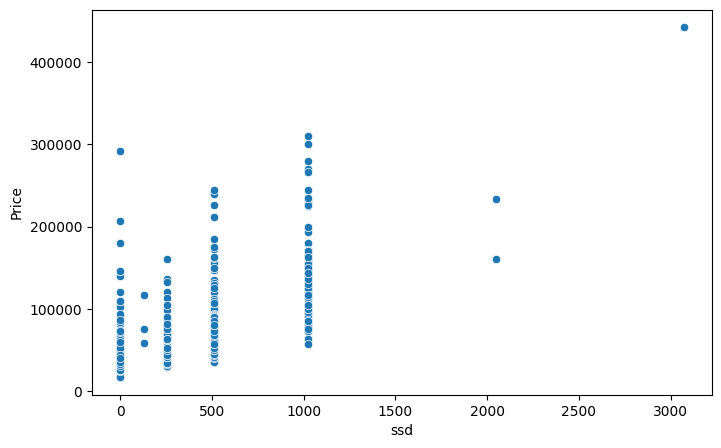

In [86]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ssd",
    y="Price"
)

plt.show()

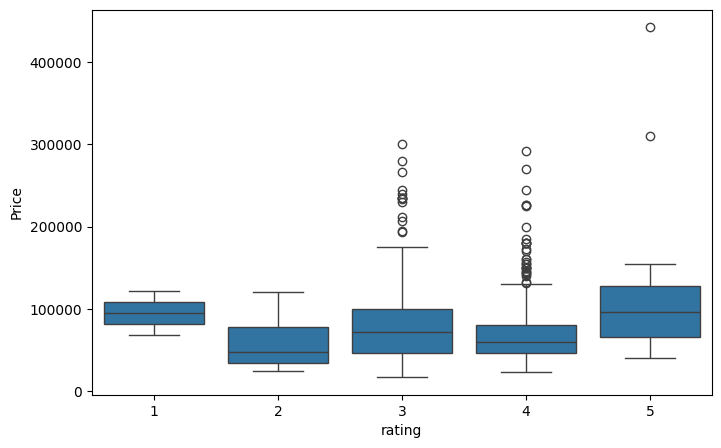

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="rating",
    y="Price"
)

plt.show()

In [91]:
X , y = df.drop("Price", axis=1), df["Price"]

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 )

In [94]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((641, 46), (161, 46), (641,), (161,))

In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
model_1 = LinearRegression()

In [98]:
model_1.fit(X_train, y_train)

LinearRegression()

In [99]:
y_pred = model_1.predict(X_test)

In [101]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [102]:
predictions.head(10)

,Actual,Predicted
677,59490,57873.076332
126,41790,53018.427167
286,87990,80862.951269
611,131990,149255.514188
370,149990,110285.789836
84,23490,20464.340521
816,138990,154530.627791
329,57990,63991.096084
90,42990,43494.066366
698,60990,50711.361473


In [111]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import numpy as np

In [114]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [115]:
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 15239.65
MSE  : 676950250.98
RMSE : 26018.27
R²   : 0.6789


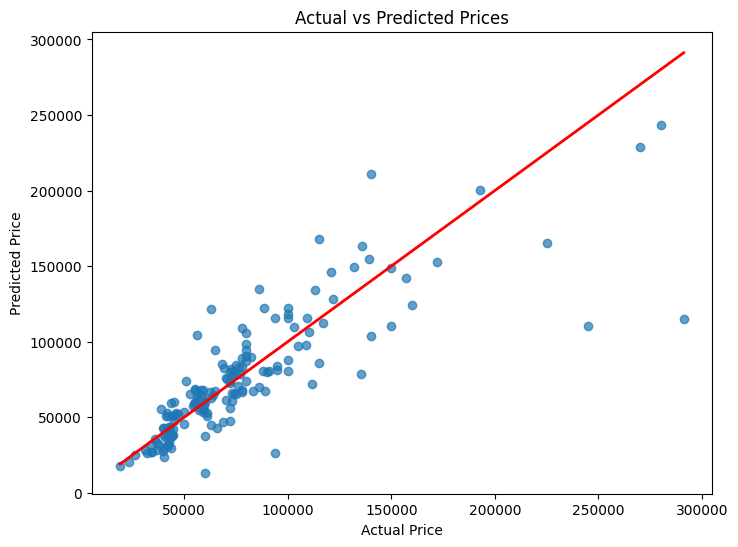

In [116]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [128]:
import joblib

joblib.dump(model_1, "model_1.pkl")

['model_1.pkl']

In [129]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']